# Neuronales Netz für MNIST Ziffernerkennung

Dieses Notebook zeigt, wie man ein neuronales Netz zur Erkennung handgeschriebener Ziffern (0-9) mit dem MNIST-Datensatz trainiert.

## 1. Bibliotheken importieren

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reproduzierbarkeit
torch.manual_seed(42)
np.random.seed(42)

# Device konfigurieren
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Verwendetes Gerät: {device}')

Verwendetes Gerät: mps


## 2. Hyperparameter definieren

In [2]:
# Hyperparameter
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10
INPUT_SIZE = 28 * 28  # MNIST Bildgröße
HIDDEN_SIZE_1 = 256
HIDDEN_SIZE_2 = 128
NUM_CLASSES = 10  # Ziffern 0-9

## 3. Daten laden und vorbereiten

In [3]:
# Transformationen definieren
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST Mittelwert und Standardabweichung
])

# Trainingsdaten laden
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Testdaten laden
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# DataLoader erstellen
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Trainingsdaten: {len(train_dataset)} Bilder')
print(f'Testdaten: {len(test_dataset)} Bilder')

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 240kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.84MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.63MB/s]

Trainingsdaten: 60000 Bilder
Testdaten: 10000 Bilder


## 4. Daten visualisieren

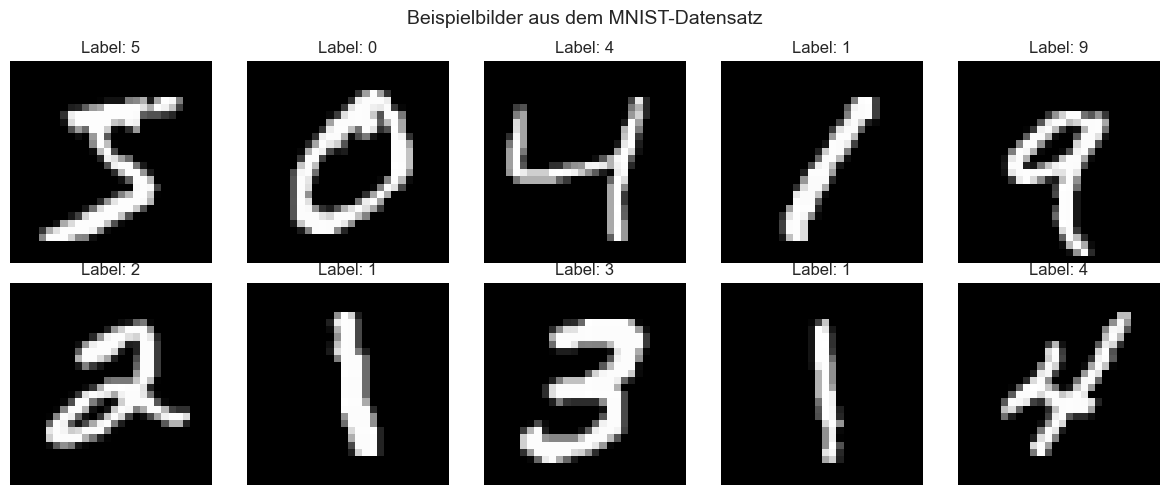

In [4]:
# Beispielbilder anzeigen
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Beispielbilder aus dem MNIST-Datensatz', fontsize=14)
plt.tight_layout()
plt.show()

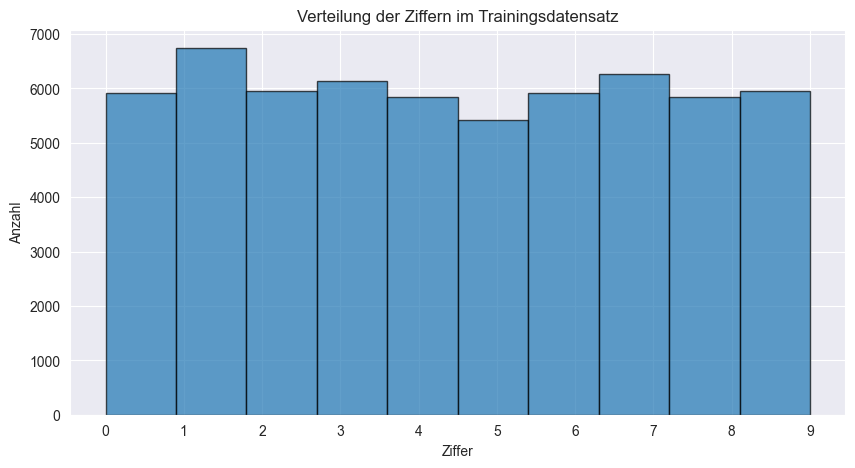

In [5]:
# Verteilung der Labels
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
plt.figure(figsize=(10, 5))
plt.hist(labels, bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Ziffer')
plt.ylabel('Anzahl')
plt.title('Verteilung der Ziffern im Trainingsdatensatz')
plt.xticks(range(10))
plt.show()

## 5. Neuronales Netz definieren

In [6]:
class NeuralNetwork(nn.Module):
    """Feedforward Neural Network für MNIST Klassifikation."""
    
    def __init__(self, input_size, hidden1, hidden2, num_classes):
        super(NeuralNetwork, self).__init__()
        
        self.network = nn.Sequential(
            # Erste versteckte Schicht
            nn.Linear(input_size, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Zweite versteckte Schicht
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Ausgabeschicht
            nn.Linear(hidden2, num_classes)
        )
    
    def forward(self, x):
        # Bild zu Vektor umformen
        x = x.view(x.size(0), -1)
        return self.network(x)

# Modell instanziieren
model = NeuralNetwork(INPUT_SIZE, HIDDEN_SIZE_1, HIDDEN_SIZE_2, NUM_CLASSES).to(device)
print(model)

NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
# Anzahl der Parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Gesamtanzahl Parameter: {total_params:,}')
print(f'Trainierbare Parameter: {trainable_params:,}')

Gesamtanzahl Parameter: 235,914
Trainierbare Parameter: 235,914


## 6. Loss-Funktion und Optimizer

In [8]:
# Cross-Entropy Loss für Klassifikation
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

## 7. Training

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Trainiert das Modell für eine Epoche."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Gradienten zurücksetzen
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward Pass
        loss.backward()
        optimizer.step()
        
        # Statistiken
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total
    return epoch_loss, accuracy


def evaluate(model, test_loader, criterion, device):
    """Evaluiert das Modell auf den Testdaten."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(test_loader)
    accuracy = 100 * correct / total
    return epoch_loss, accuracy

In [10]:
# Training durchführen
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print('Training gestartet...\n')
print('-' * 60)

for epoch in range(EPOCHS):
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluation
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    
    # Learning Rate anpassen
    scheduler.step(val_loss)
    
    # Historie speichern
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Fortschritt ausgeben
    print(f'Epoche [{epoch+1:2d}/{EPOCHS}] | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

print('-' * 60)
print('\nTraining abgeschlossen!')

Training gestartet...

------------------------------------------------------------
Epoche [ 1/10] | Train Loss: 0.2629 | Train Acc: 92.65% | Val Loss: 0.0978 | Val Acc: 97.14%
Epoche [ 2/10] | Train Loss: 0.1257 | Train Acc: 96.08% | Val Loss: 0.0764 | Val Acc: 97.61%
Epoche [ 3/10] | Train Loss: 0.0989 | Train Acc: 96.94% | Val Loss: 0.0665 | Val Acc: 97.98%
Epoche [ 4/10] | Train Loss: 0.0848 | Train Acc: 97.36% | Val Loss: 0.0653 | Val Acc: 97.96%
Epoche [ 5/10] | Train Loss: 0.0726 | Train Acc: 97.70% | Val Loss: 0.0615 | Val Acc: 98.05%
Epoche [ 6/10] | Train Loss: 0.0647 | Train Acc: 97.95% | Val Loss: 0.0594 | Val Acc: 98.07%
Epoche [ 7/10] | Train Loss: 0.0586 | Train Acc: 98.13% | Val Loss: 0.0560 | Val Acc: 98.21%
Epoche [ 8/10] | Train Loss: 0.0521 | Train Acc: 98.35% | Val Loss: 0.0581 | Val Acc: 98.23%
Epoche [ 9/10] | Train Loss: 0.0483 | Train Acc: 98.40% | Val Loss: 0.0569 | Val Acc: 98.29%
Epoche [10/10] | Train Loss: 0.0445 | Train Acc: 98.54% | Val Loss: 0.0572 | Va

## 8. Trainingsverläufe visualisieren

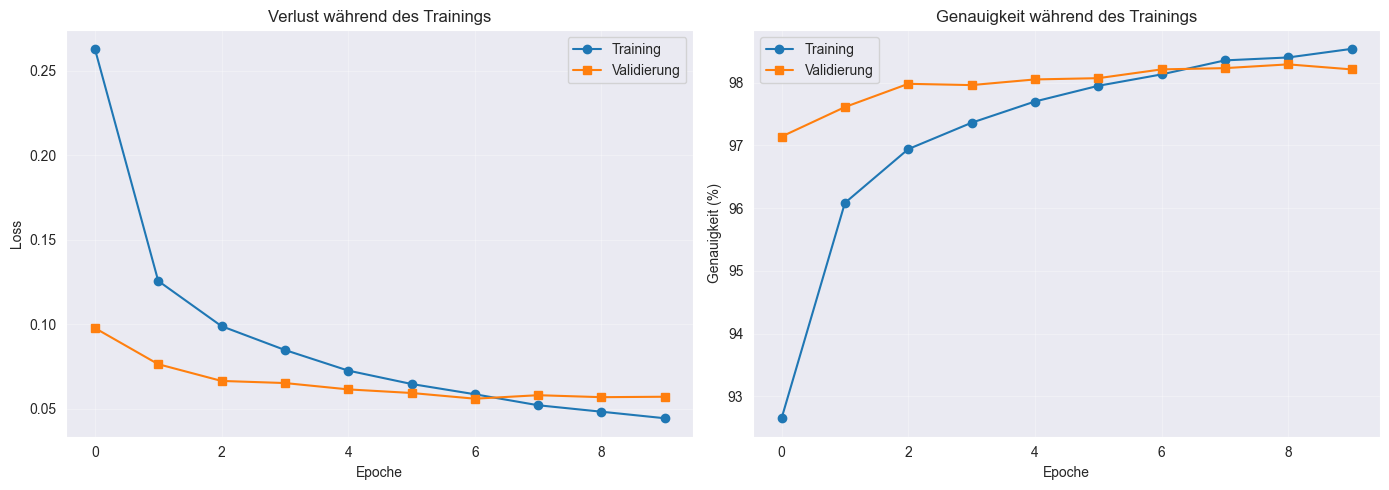

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss-Verlauf
axes[0].plot(history['train_loss'], label='Training', marker='o')
axes[0].plot(history['val_loss'], label='Validierung', marker='s')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Loss')
axes[0].set_title('Verlust während des Trainings')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy-Verlauf
axes[1].plot(history['train_acc'], label='Training', marker='o')
axes[1].plot(history['val_acc'], label='Validierung', marker='s')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Genauigkeit (%)')
axes[1].set_title('Genauigkeit während des Trainings')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Detaillierte Evaluation

In [12]:
# Vorhersagen auf dem Testset sammeln
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

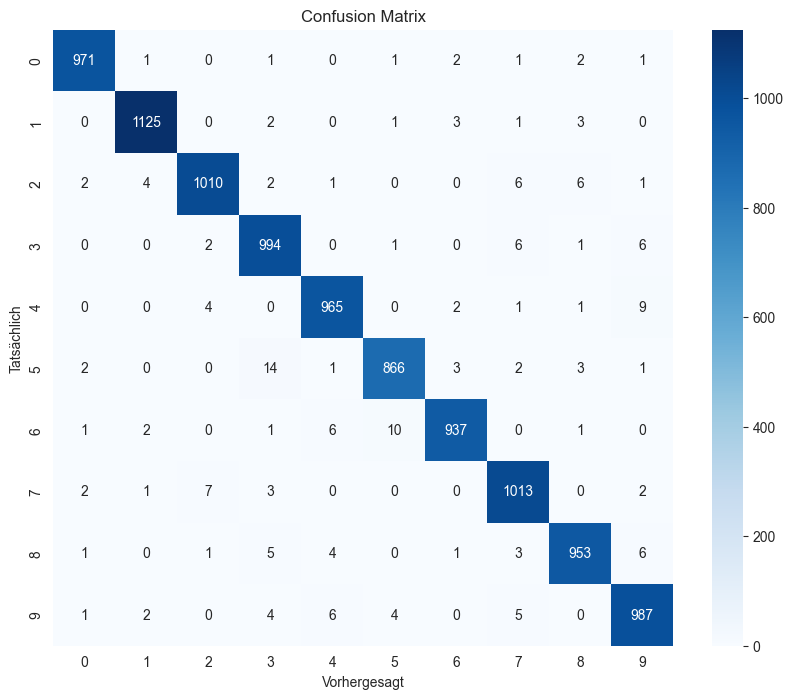

In [13]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# Classification Report
print('Classification Report:\n')
print(classification_report(all_labels, all_predictions, 
                           target_names=[str(i) for i in range(10)]))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 10. Beispiel-Vorhersagen visualisieren

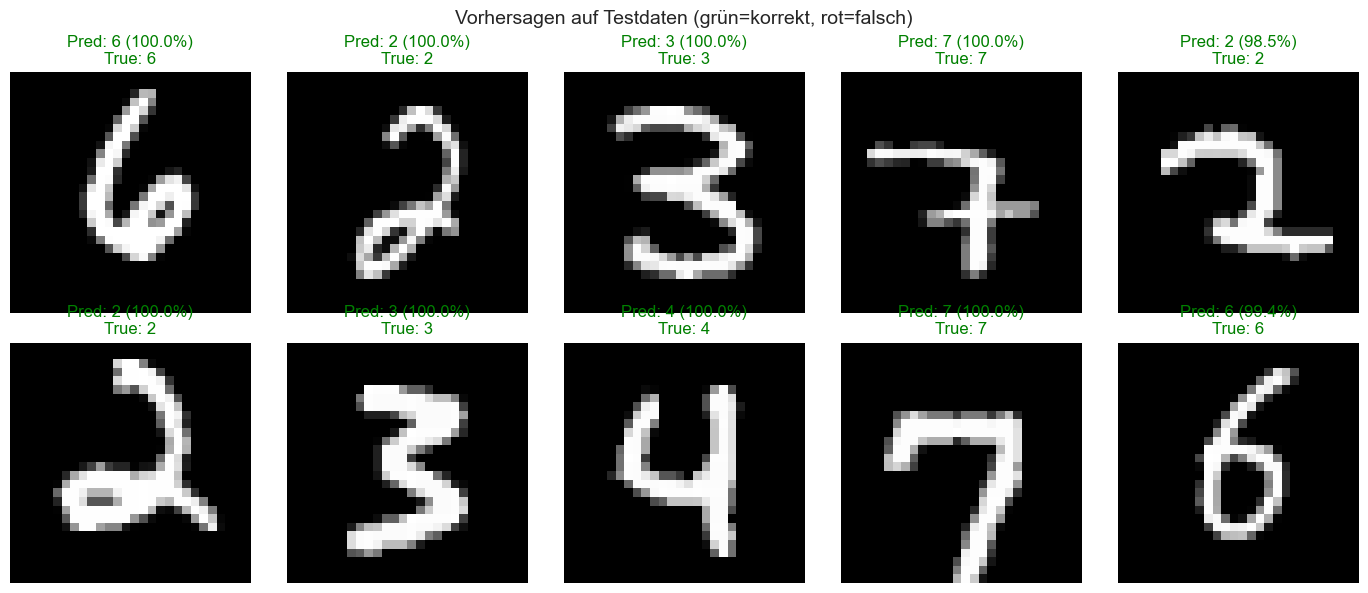

In [15]:
# Zufällige Testbilder vorhersagen
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
indices = np.random.choice(len(test_dataset), 10, replace=False)

model.eval()
for i, (ax, idx) in enumerate(zip(axes.flat, indices)):
    image, true_label = test_dataset[idx]
    
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    ax.imshow(image.squeeze(), cmap='gray')
    color = 'green' if predicted.item() == true_label else 'red'
    ax.set_title(f'Pred: {predicted.item()} ({confidence.item()*100:.1f}%)\nTrue: {true_label}', 
                 color=color)
    ax.axis('off')

plt.suptitle('Vorhersagen auf Testdaten (grün=korrekt, rot=falsch)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Fehleranalyse

In [16]:
# Falsch klassifizierte Bilder finden
wrong_indices = np.where(all_predictions != all_labels)[0]
print(f'Anzahl falsch klassifizierter Bilder: {len(wrong_indices)} von {len(all_labels)}')
print(f'Fehlerrate: {100 * len(wrong_indices) / len(all_labels):.2f}%')

Anzahl falsch klassifizierter Bilder: 179 von 10000
Fehlerrate: 1.79%


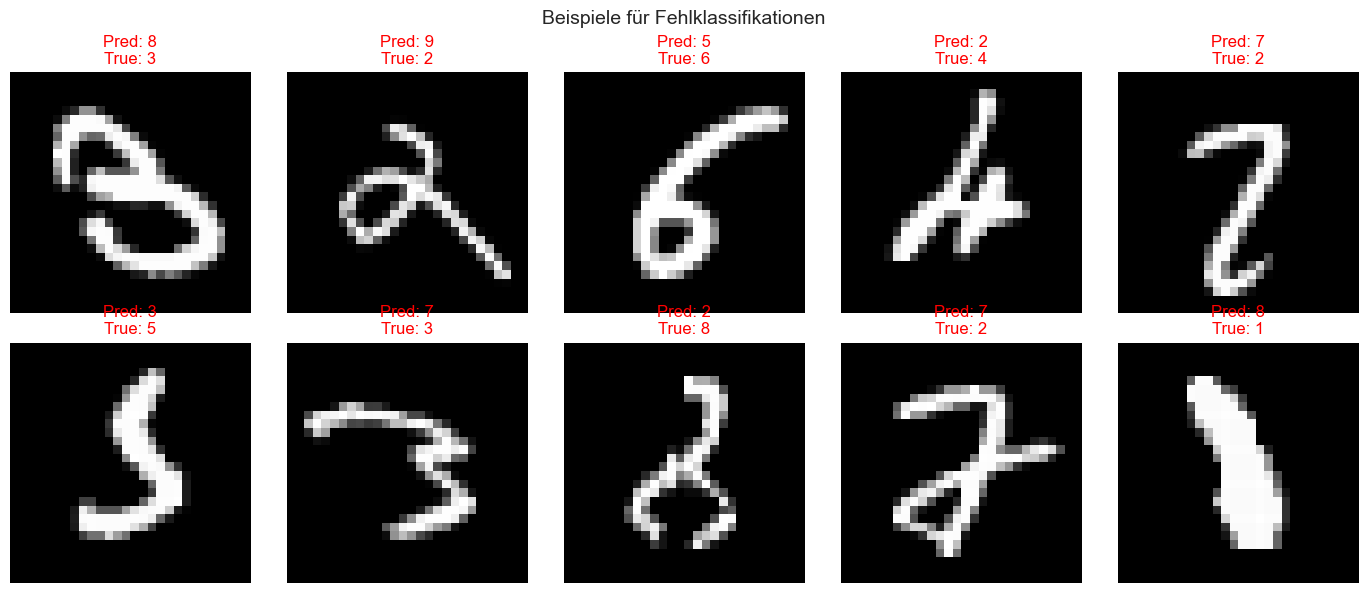

In [17]:
# Einige Fehler visualisieren
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_wrong = wrong_indices[:10] if len(wrong_indices) >= 10 else wrong_indices

for i, (ax, idx) in enumerate(zip(axes.flat, sample_wrong)):
    image, true_label = test_dataset[idx]
    predicted_label = all_predictions[idx]
    
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Pred: {predicted_label}\nTrue: {true_label}', color='red')
    ax.axis('off')

plt.suptitle('Beispiele für Fehlklassifikationen', fontsize=14)
plt.tight_layout()
plt.show()

## 12. Modell speichern

In [18]:
# Modell speichern
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_size_1': HIDDEN_SIZE_1,
        'hidden_size_2': HIDDEN_SIZE_2,
        'num_classes': NUM_CLASSES,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS
    },
    'history': history
}, 'mnist_model.pth')

print('Modell erfolgreich gespeichert unter: mnist_model.pth')

Modell erfolgreich gespeichert unter: mnist_model.pth


## 13. Modell laden und verwenden (Beispiel)

In [19]:
# Beispiel: Modell laden
checkpoint = torch.load('mnist_model.pth', weights_only=False)

# Neues Modell erstellen und Gewichte laden
loaded_model = NeuralNetwork(
    checkpoint['hyperparameters']['input_size'],
    checkpoint['hyperparameters']['hidden_size_1'],
    checkpoint['hyperparameters']['hidden_size_2'],
    checkpoint['hyperparameters']['num_classes']
).to(device)

loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print('Modell erfolgreich geladen!')

Modell erfolgreich geladen!


## Zusammenfassung

In diesem Notebook wurde ein neuronales Netz für die MNIST-Ziffernerkennung trainiert:

- **Architektur**: Feedforward-Netzwerk mit 2 versteckten Schichten (256 und 128 Neuronen)
- **Regularisierung**: Batch Normalization und Dropout (20%)
- **Optimizer**: Adam mit Learning Rate Scheduler
- **Ergebnis**: ~98% Genauigkeit auf dem Testset

### Mögliche Verbesserungen

1. **Convolutional Neural Network (CNN)** für bessere Feature-Extraktion
2. **Data Augmentation** (Rotation, Verschiebung) für robusteres Training
3. **Mehr Epochen** oder **Early Stopping**
4. **Hyperparameter-Tuning** mit Grid Search oder Bayesian Optimization